# Hidden Markov models: finding market regimes you cannot see directly

The chains in notebooks 01 and 02 had one convenient property we never
questioned: the state was visible. You could look at a loan and see
"risky". This notebook removes that convenience, because the most
interesting systems refuse to show you their state.

Markets are the classic case. Anyone who has watched prices for a while
develops the sense that the market has moods: long stretches where
everything grinds calmly upward, and episodes where volatility explodes
and correlations go to one. Practitioners call these **regimes**. The
trouble is that no exchange publishes a regime ticker. Nobody rings a
bell when calm ends. All you observe are symptoms: daily returns, the
level of fear priced into options, the shape of the yield curve.

A **hidden Markov model** (HMM) formalizes exactly this situation. It
says: there is a Markov chain running underneath, just like notebook
01's, but its state $z_t$ is invisible. What you see each day is an
observation $x_t$ drawn from a probability distribution that depends on
the hidden state. Three ingredients pin the model down:

1. **Starting probabilities**: where the hidden chain begins.
2. **A transition matrix**: the same object you already know, governing
   how regimes persist and switch, day to day.
3. **Emission distributions**: one per hidden state, describing what the
   visible data tends to look like when the system is in that state.
   Here each state gets a multivariate Gaussian, so "calm" might mean
   small returns and a low fear gauge, with stress the opposite.

Fitting is done by an algorithm called expectation-maximization (EM,
also known as Baum-Welch in this setting). You do not need its internals
to use it, but the loop is worth one sentence: guess the parameters,
infer how probably each day belongs to each hidden state, re-estimate
the parameters from those weighted days, and repeat until nothing moves.
After fitting, `predict` returns the single most likely state sequence,
and `predict_proba` returns the day-by-day probabilities behind it.

The plan for this notebook, and it is a deliberate one:

- **Warm up on synthetic data** where we know the true regimes, because
  that is the only way to verify the machinery end to end.
- **Meet the real dataset**: sixteen years of prices and macro series,
  with each feature explained.
- **Choose the number of regimes honestly**, including watching the
  standard textbook criterion fail.
- **Fit, and name the regimes from their fitted statistics**, not from
  our hopes.
- **Compare against a memoryless competitor** to see what the hidden
  chain is actually buying us.
- **Read the fitted transition matrix** with notebook 01's tools.
- **Test out of sample** on years the model has never seen.

In [1]:
import sys
import warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

# scikit-learn's k-means initializer trips harmless matmul warnings on
# some BLAS builds; silence them so the outputs stay readable.
warnings.filterwarnings('ignore', message='.*encountered in matmul.*')

np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

BLUE, ORANGE, GREEN = '#2a78d6', '#eb6834', '#1baf7a'
AMBER, RED, INK = '#fab219', '#d03b3b', '#333333'

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#666666', 'axes.linewidth': 0.9,
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.titlesize': 13, 'axes.titleweight': 'semibold',
    'axes.titlelocation': 'left', 'axes.titlecolor': INK,
    'axes.labelsize': 11, 'axes.labelcolor': '#444444',
    'xtick.color': '#666666', 'ytick.color': '#666666',
    'legend.frameon': False, 'font.size': 11,
})

COLORS = {'calm, steep curve': BLUE,
          'calm, flat curve': GREEN,
          'stress': ORANGE}

def regime_spans(seq):
    """Contiguous (first, last, state) runs in a state sequence."""
    spans, s = [], 0
    for t in range(1, len(seq) + 1):
        if t == len(seq) or seq[t] != seq[s]:
            spans.append((s, t - 1, seq[s]))
            s = t
    return spans

## Warm-up: data where we know the answer

Before pointing an HMM at markets, point it at data we manufactured
ourselves. This is the honest way to learn any fitting procedure: on
synthetic data the true hidden states are known, so we can grade the
model's homework exactly, which real data never allows.

The generative story, spelled out. Each day the hidden regime follows a
sticky two-state chain: calm days stay calm with probability 0.98,
stress days stay stressed with probability 0.96. The visible data is a
single daily return drawn from that day's regime: calm days from a
Gaussian with a slight upward drift and small wiggle, stress days from
one with a downward drift and wiggles three times as large. Ten years
of trading days, then we hand the model *only the returns* and ask it
to reconstruct everything else.

In [2]:
true_T = np.array([[0.98, 0.02],
                   [0.04, 0.96]])
true_mu = np.array([0.0005, -0.0010])      # calm drifts up, stress down
true_sigma = np.array([0.007, 0.021])      # stress is 3x noisier

rng = np.random.default_rng(3)
n_days = 2520                              # ten years of trading days
z = np.zeros(n_days, dtype=int)
for t in range(1, n_days):
    z[t] = rng.choice(2, p=true_T[z[t - 1]])
r = rng.normal(true_mu[z], true_sigma[z])

toy = GaussianHMM(n_components=2, covariance_type='full',
                  n_iter=500, random_state=0).fit(r.reshape(-1, 1))
raw = toy.predict(r.reshape(-1, 1))

# The model numbers its states arbitrarily, so align labels before
# grading: whichever fitted state has the larger variance plays 'stress'.
sig_hat = np.sqrt([toy.covars_[k].ravel()[0] for k in range(2)])
perm = np.argsort(sig_hat)                 # calm first, stress second
z_hat = np.empty_like(raw)
for new, old in enumerate(perm):
    z_hat[raw == old] = new

print(f"days labeled correctly: {(z_hat == z).mean():.1%}\n")
recovered = pd.DataFrame(
    {'true stay-prob': np.diag(true_T),
     'recovered stay-prob': np.diag(toy.transmat_[np.ix_(perm, perm)]),
     'true daily vol': true_sigma,
     'recovered daily vol': sig_hat[perm]},
    index=['calm', 'stress'])
recovered.round(4)

days labeled correctly: 96.8%



,true stay-prob,recovered stay-prob,true daily vol,recovered daily vol
calm,0.98,0.9875,0.007,0.0076
stress,0.96,0.9658,0.021,0.0206


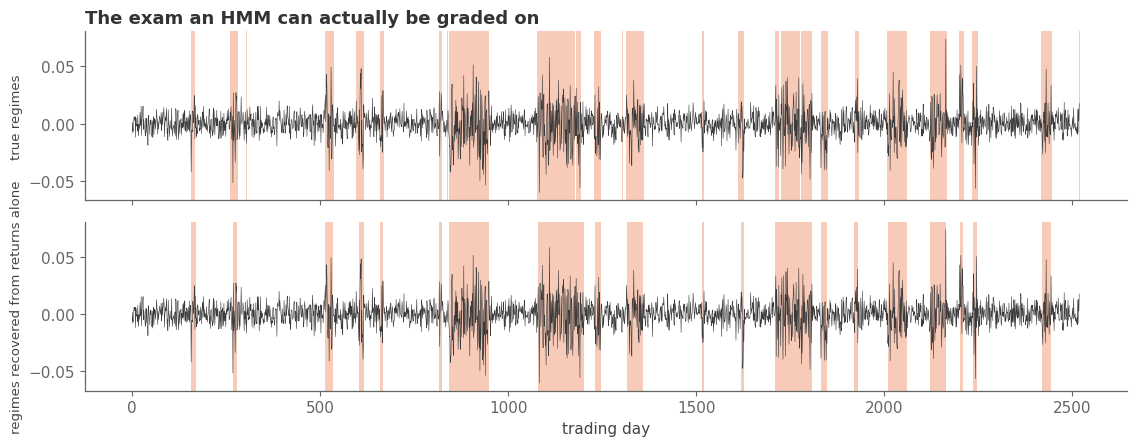

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(11.5, 4.6), sharex=True)
for ax, seq, label in ((axes[0], z, 'true regimes'),
                       (axes[1], z_hat, 'regimes recovered from returns alone')):
    for a, b, sid in regime_spans(seq):
        if sid == 1:
            ax.axvspan(a, b + 1, color=ORANGE, alpha=0.35, lw=0)
    ax.plot(r, lw=0.4, color='#3b3b3b')
    ax.set_ylabel(label, fontsize=9.5)
    ax.grid(False)
axes[0].set_title('The exam an HMM can actually be graded on')
axes[1].set_xlabel('trading day')
fig.tight_layout()

The two panels are nearly identical: given nothing but the returns, the
model relabels the vast majority of days correctly and recovers both
the stickiness of the hidden chain and the volatility of each regime to
a couple of decimal places. When the data genuinely comes from an HMM,
the machinery works.

Carry the caveat with you, though: real markets did not sign a contract
to behave like two Gaussians glued together by a chain. On real data the
HMM is a lens, not the truth, and everything below should be read with
that skepticism. That is also why the naming step later works from
fitted statistics instead of assuming the states mean what we want them
to mean.

## The real dataset

One CSV, versioned with the repository, covering January 2010 to August
2026. Four observable features per trading day:

- **SPY** is an exchange-traded fund tracking the S&P 500, the
  workhorse yardstick for "the US stock market". We model its daily
  **log return**, `sret = ln(price_t / price_{t-1})`, rather than the
  price itself: returns put every era on the same scale (a 10-dollar
  move meant something different in 2010 than in 2026), and log returns
  add up cleanly across days.
- **VIXCLS** is the VIX, the market's fear gauge: the volatility implied
  by S&P 500 option prices over the next month. Around 12 to 15 the
  market is drowsy; above 20 it is nervous; above 40 something is
  breaking.
- **T10Y2Y** and **T10Y3M** are yield-curve spreads: the 10-year
  Treasury rate minus the 2-year, and minus the 3-month. The curve's
  shape tracks the interest-rate cycle. Steep (large spreads) is the
  classic early-cycle backdrop of easy money; flat or inverted
  (negative spreads) marks late cycle, and inversions have preceded
  every modern US recession.

Returns and fear describe the market's mood; the two spreads anchor
which chapter of the macro cycle we are in. Four features, each cheap
to explain, and that is deliberate: whatever regimes the model finds,
it can only define them in terms of these inputs, so inputs you cannot
explain produce regimes you cannot explain.

A note on plumbing, because it is the reason this rewrite exists. The
2020 version of this notebook pulled prices from a free API that has
since shut down, and used two FRED series that have since died: the TED
spread was discontinued in 2022, and the high-yield credit spread moved
behind a license that only exposes recent history. The data now ships
with the repository so results reproduce exactly, and
`data/build_dataset.py` rebuilds the snapshot from sources that remain
fully open.

,SPY,VIXCLS,T10Y2Y,T10Y3M,sret
Date,,,,,
2026-07-31,747.03,15.99,0.47,0.92,0.0072
2026-08-03,757.67,15.86,0.45,0.79,0.0141
2026-08-04,771.33,15.86,0.43,0.74,0.0179


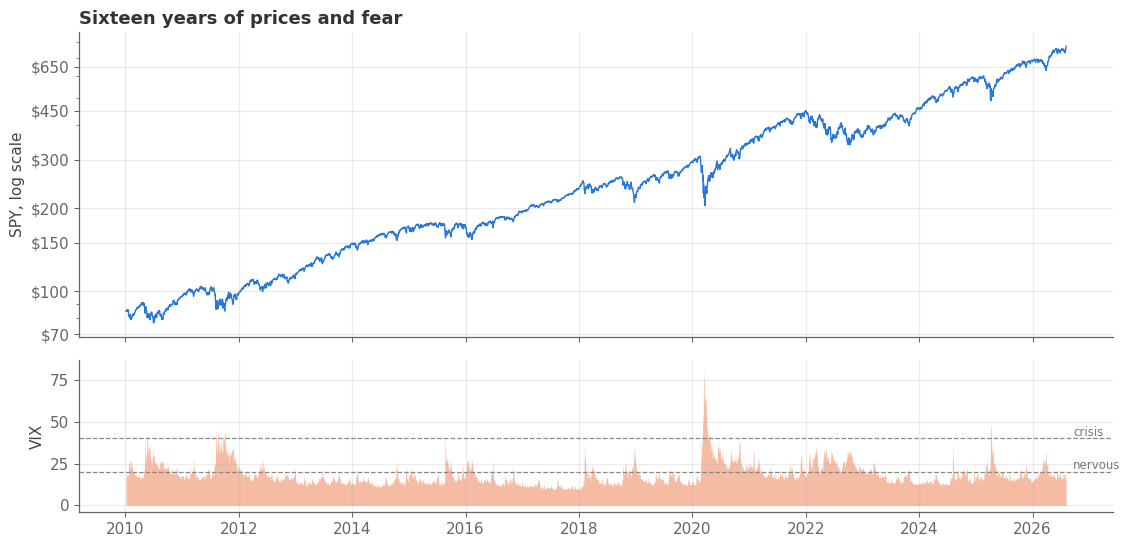

In [4]:
df = pd.read_csv('../data/market_macro.csv', index_col=0, parse_dates=True)
FEATURES = ['VIXCLS', 'T10Y2Y', 'T10Y3M', 'sret']

fig, axes = plt.subplots(2, 1, figsize=(11.5, 5.6), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]})
axes[0].plot(df.index, df['SPY'], color=BLUE, lw=1.0)
axes[0].set_yscale('log')
axes[0].set_yticks([70, 100, 150, 200, 300, 450, 650])
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
axes[0].yaxis.set_minor_formatter(mticker.NullFormatter())
axes[0].set_ylabel('SPY, log scale')
axes[0].set_title('Sixteen years of prices and fear')

axes[1].fill_between(df.index, df['VIXCLS'], color=ORANGE, alpha=0.45, lw=0)
axes[1].axhline(20, color='#888888', ls='--', lw=0.9)
axes[1].axhline(40, color='#888888', ls='--', lw=0.9)
axes[1].annotate('nervous', xy=(df.index[-1], 20), xytext=(5, 2),
                 textcoords='offset points', fontsize=8.5, color='#777777')
axes[1].annotate('crisis', xy=(df.index[-1], 40), xytext=(5, 2),
                 textcoords='offset points', fontsize=8.5, color='#777777')
axes[1].set_ylabel('VIX')
fig.tight_layout()

df.tail(3).round(4)

Every VIX spike in the lower panel lines up with a dent or crash in the
upper one. The model is about to systematize that eyeball observation.

## Split first, scale second

Two pieces of discipline before any fitting, both about not cheating.

**The split.** Train on 2010 through 2021, hold out 2022 onward. The
holdout is not generous by accident: it contains the 2022 bear market,
the recovery after it, and everything since, so the fitted regimes will
be examined on stress they have never seen. A regime model graded only
on its training years is a story, not a model.

**The scaling.** The features live on wildly different scales: VIX
around 20, spreads around 1, returns around 0.01. Standardizing each
feature (subtract its mean, divide by its standard deviation) puts them
on one footing so the Gaussians are fitted in comparable units, and it
keeps the numerics of EM comfortable.

The order is the part people get wrong: the scaler is fitted **on the
training window only**, then applied to both windows. Fit it on all
sixteen years and the means and variances would carry information from
2022 onward back into a model that is supposed to have never seen those
years. This quiet mistake is called leakage, it inflates out-of-sample
results, and it is entirely avoidable, so avoid it.

In [5]:
train = df.loc[:'2021-12-31']
test = df.loc['2022-01-01':]

scaler = StandardScaler().fit(train[FEATURES])
X_train = scaler.transform(train[FEATURES])
X_test = scaler.transform(test[FEATURES])

print(f"train: {len(train)} days, {train.index.min().date()} to {train.index.max().date()}")
print(f"test : {len(test)} days, {test.index.min().date()} to {test.index.max().date()}")

train: 3020 days, 2010-01-05 to 2021-12-31
test : 1150 days, 2022-01-03 to 2026-08-04


## How many regimes? Watch the textbook answer fail

The number of hidden states is a choice, and the standard advice says:
sweep over candidates and let an information criterion decide. **BIC**
(the Bayesian information criterion) scores a model as *badness of fit
plus a penalty per parameter*, so lower is better, and the penalty is
supposed to stop you from buying tiny fit improvements with ever more
parameters.

We run the sweep on Gaussian mixtures, which share the HMM's emission
structure without the chain (making them fast and stable to fit many
times), and we watch what happens.

,BIC,AIC
k,,
1,26072.0,25987.0
2,23010.0,22835.0
3,22263.0,21998.0
4,20745.0,20390.0
5,19046.0,18601.0
6,18410.0,17875.0


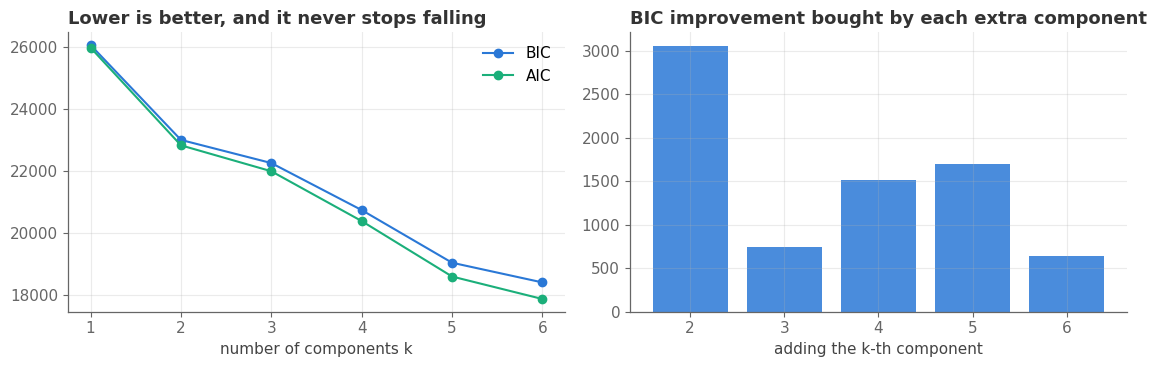

In [6]:
rows = []
for k in range(1, 7):
    gm = GaussianMixture(n_components=k, covariance_type='full',
                         n_init=20, random_state=42).fit(X_train)
    rows.append((k, gm.bic(X_train), gm.aic(X_train)))
sweep = pd.DataFrame(rows, columns=['k', 'BIC', 'AIC']).set_index('k')

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
axes[0].plot(sweep.index, sweep['BIC'], marker='o', color=BLUE, label='BIC')
axes[0].plot(sweep.index, sweep['AIC'], marker='o', color=GREEN, label='AIC')
axes[0].set_xlabel('number of components k')
axes[0].set_title('Lower is better, and it never stops falling')
axes[0].legend()

drops = -sweep['BIC'].diff().dropna()
axes[1].bar(drops.index, drops, color=BLUE, alpha=0.85)
axes[1].set_xlabel('adding the k-th component')
axes[1].set_title('BIC improvement bought by each extra component')
fig.tight_layout()

sweep.round(0)

BIC falls all the way to six components and would keep falling if we let
it run. On fat-tailed financial data this is typical rather than a bug
in the code. Daily returns produce far more extreme days than any single
Gaussian allows, so every additional component gets spent buying a
better description of the tails, and the likelihood gain keeps beating
the parameter penalty. The criterion is answering "do more Gaussians fit
this data better?" (yes, indefinitely) rather than the question we
actually asked, "how many economic regimes are there?". On features like
these, BIC is a weak referee.

The right-hand panel adds a telling detail: the first split (one
component to two) buys by far the biggest improvement, but after that
the increments do not even decline in an orderly way. The fourth and
fifth components each buy more than the third did, which is what you
expect from a criterion chasing different pockets of the tails rather
than discovering structure one regime at a time. So the honest
selection argument runs on interpretability. Three states is the smallest number that maps onto a
reading a practitioner can act on, and the deal I make with the model
is explicit: I choose three, then hold the fitted states accountable.
If they had come out unreadable, that would be the signal to revisit
the choice, not to squint harder.

## Fit, then name what actually came out

One genuine gotcha before fitting: the model returns its states in
arbitrary order. State 0 is not "calm" because you hoped it would be;
run the same fit with another seed and the labels shuffle. So naming
must be earned from the fitted statistics. The rule used here: the
state with the highest average VIX is **stress**, and the two remaining
calm states are split by the slope of the yield curve, **steep** versus
**flat**. The rule is written as a function because we will reuse it on
a second model later.

In [7]:
hmm = GaussianHMM(n_components=3, covariance_type='full',
                  n_iter=1000, random_state=42).fit(X_train)
states_train = hmm.predict(X_train)

def name_states(frame, seq):
    """Name states from fitted behavior: VIX finds stress, the curve
    slope separates the two calm states."""
    prof = (frame.assign(state=seq).groupby('state')
            .agg(mean_vix=('VIXCLS', 'mean'), mean_slope=('T10Y2Y', 'mean')))
    stress = prof['mean_vix'].idxmax()
    calms = [i for i in prof.index if i != stress]
    steep = prof.loc[calms, 'mean_slope'].idxmax()
    flat = [i for i in calms if i != steep][0]
    return {steep: 'calm, steep curve', flat: 'calm, flat curve',
            stress: 'stress'}

NAMES = name_states(train, states_train)

profile = (train.assign(state=states_train)
           .groupby('state')
           .agg(days=('sret', 'size'),
                ann_return=('sret', lambda s: s.mean() * 252),
                ann_vol=('sret', lambda s: s.std() * np.sqrt(252)),
                mean_vix=('VIXCLS', 'mean'),
                mean_t10y2y=('T10Y2Y', 'mean')))
profile.index = [NAMES[i] for i in profile.index]
profile.round(3)

,days,ann_return,ann_vol,mean_vix,mean_t10y2y
"calm, steep curve",964,0.158,0.112,15.279,2.066
"calm, flat curve",1130,0.205,0.111,15.370,1.048
stress,926,0.038,0.257,24.465,0.947


This table contains the notebook's most interesting finding, and it is
not the one I went looking for.

The stress state is unmistakable: average VIX in the mid twenties,
annualized volatility above 25%, returns going nowhere. That is the
regime containing the euro crisis, the 2015 to 2016 wobbles, the late
2018 selloff, and March 2020.

The surprise is the other two states. I expected something like
"strong bull" versus "weak grind". Instead the model produced two calm
states with essentially the *same* volatility, around 11% annualized,
separated almost entirely by the yield curve: one lives where the curve
is steep (average 10y minus 2y spread above two points, the easy-money
recovery years of roughly 2010 to 2017), the other where the curve is
flat (the late-cycle years). The model split calm along the macro
dimension we handed it, not the price dimension I was imagining.

There is a general lesson in that. Unsupervised models answer the
question your features ask, not the question in your head. Feed a
regime model the yield curve and its regimes will know about the rate
cycle. This is a feature when you notice it and a trap when you do
not.

Here are the sixteen training years painted with the fitted regimes.

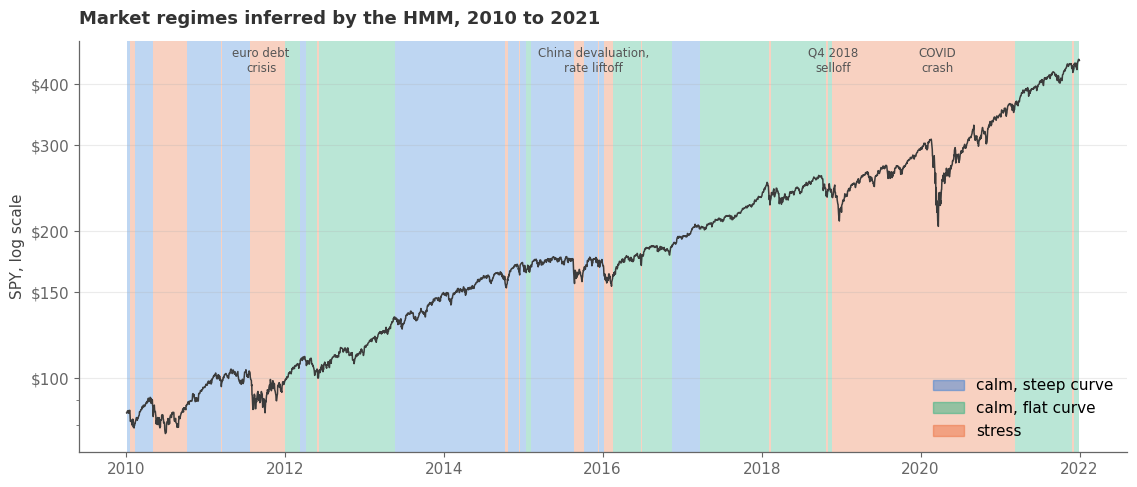

In [8]:
def plot_regimes(frame, state_seq, names, title, path=None, notes=()):
    """SPY on a log scale over shaded regime bands."""
    fig, ax = plt.subplots(figsize=(11.5, 5))
    last = len(frame) - 1
    for a, b, sid in regime_spans(state_seq):
        ax.axvspan(frame.index[a], frame.index[min(b + 1, last)],
                   color=COLORS[names[sid]], alpha=0.30, lw=0)
    ax.plot(frame.index, frame['SPY'], color='#3b3b3b', lw=1.1)
    ax.set_yscale('log')
    lo, hi = frame['SPY'].min(), frame['SPY'].max()
    ticks = [t for t in (50, 70, 100, 150, 200, 300, 400, 550, 750)
             if lo * 0.92 <= t <= hi * 1.12]
    ax.set_yticks(ticks)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_ylabel('SPY, log scale')
    ax.set_title(title, pad=12)
    ax.legend(handles=[mpatches.Patch(color=c, alpha=0.45, label=n)
                       for n, c in COLORS.items()], loc='lower right')
    for date, text in notes:
        ax.annotate(text, xy=(pd.Timestamp(date), 0.985),
                    xycoords=('data', 'axes fraction'),
                    ha='center', va='top', fontsize=8.5, color='#555555')
    ax.grid(axis='y', alpha=0.25)
    ax.grid(axis='x', alpha=0)
    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')

plot_regimes(train, states_train, NAMES,
             'Market regimes inferred by the HMM, 2010 to 2021',
             path='../pic/spy_regimes_hmm.png',
             notes=[('2011-09-15', 'euro debt\ncrisis'),
                    ('2015-11-20', 'China devaluation,\nrate liftoff'),
                    ('2018-11-25', 'Q4 2018\nselloff'),
                    ('2020-03-20', 'COVID\ncrash')])

The picture reads like a market history you already know. Blue years,
steep curve and recovery, carry the market out of 2010; green takes
over as the Fed lifts rates and the curve flattens in the late 2010s;
and the orange bands sit on episodes you can name, from the euro debt
crisis to the COVID crash. The model was never told any dates or
events. It found them from four daily numbers.

One detail deserves a flag rather than a gloss. The long orange band
that begins with the Q4 2018 selloff runs through 2019, a year of
mostly rising prices but also an inverting yield curve and repeated
growth scares. This model's notion of stress listens to the curve as
much as to the VIX, because we gave it the curve as a feature. Keep
that in mind; the out-of-sample test will turn it up to full volume.

## The model's confidence, not just its verdict

`predict` returns a hard call per day, but underneath sits a full
probability. `predict_proba` exposes it, and it is worth a look for two
reasons: it shows the transitions are sharp rather than dithering, and
in any governance setting (risk committees do not enjoy whiplash) you
would act on "P(stress) above 0.8 for a week", not on single-day flips.

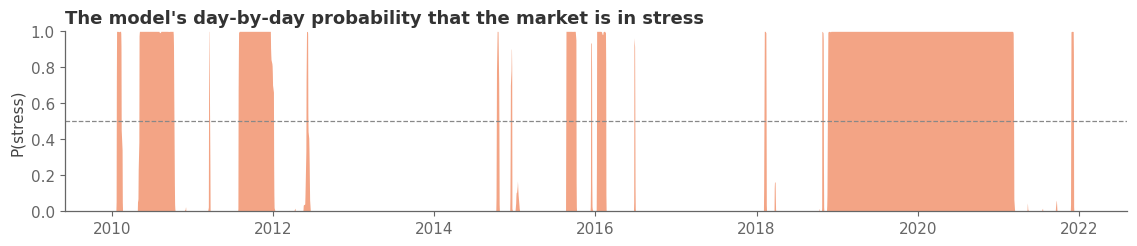

In [9]:
stress_id = [i for i, n in NAMES.items() if n == 'stress'][0]
post_stress = hmm.predict_proba(X_train)[:, stress_id]

fig, ax = plt.subplots(figsize=(11.5, 2.6))
ax.fill_between(train.index, post_stress, color=ORANGE, alpha=0.6, lw=0)
ax.axhline(0.5, color='#888888', ls='--', lw=0.9)
ax.set_ylim(0, 1)
ax.set_ylabel('P(stress)')
ax.set_title("The model's day-by-day probability that the market is in stress")
ax.grid(False)
fig.tight_layout()

## What does the hidden chain actually buy? A memoryless rival

Here is the cleanest way to see the value of the transition matrix:
delete it. A Gaussian mixture with three components has exactly the
same emission structure as our HMM, but classifies every day
independently, with no memory of yesterday. Same distributions, no
chain. If the chain were decoration, the two models would behave
alike.

In [10]:
gmm3 = GaussianMixture(n_components=3, covariance_type='full',
                       n_init=20, random_state=42).fit(X_train)
gmm_states = gmm3.predict(X_train)
GNAMES = name_states(train, gmm_states)

def switches_per_year(seq, index):
    flips = int((np.diff(seq) != 0).sum())
    years = (index.max() - index.min()).days / 365.25
    return flips / years

print(f"regime switches per year, mixture (no memory): "
      f"{switches_per_year(gmm_states, train.index):5.1f}")
print(f"regime switches per year, HMM (with memory)  : "
      f"{switches_per_year(states_train, train.index):5.1f}")

regime switches per year, mixture (no memory):  23.6
regime switches per year, HMM (with memory)  :   3.1


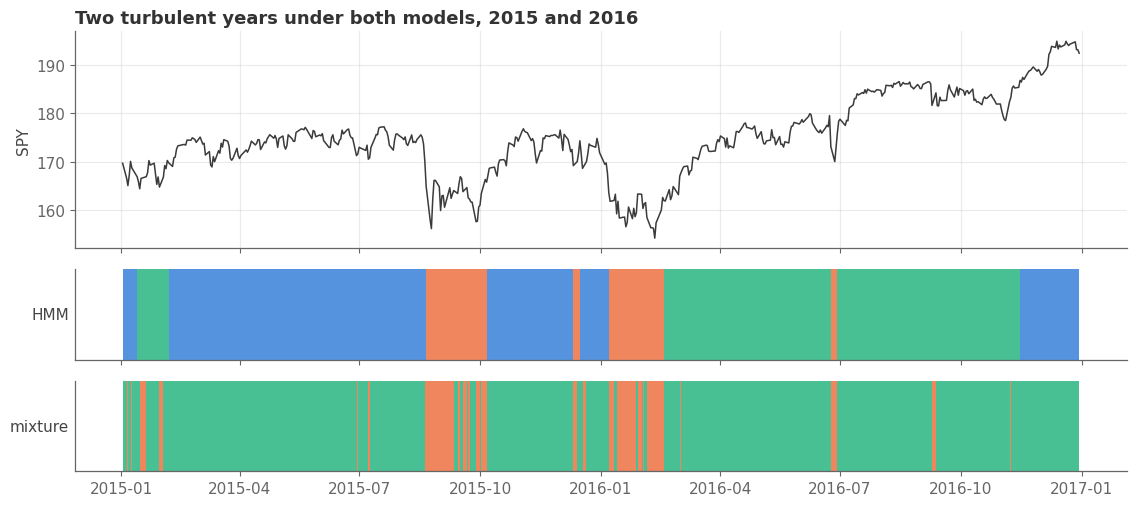

In [11]:
mask = (train.index >= '2015-01-01') & (train.index <= '2016-12-31')
zoom = train[mask]
seq_h, seq_g = states_train[mask], gmm_states[mask]

fig, axes = plt.subplots(3, 1, figsize=(11.5, 5.2), sharex=True,
                         gridspec_kw={'height_ratios': [2.4, 1, 1]})
axes[0].plot(zoom.index, zoom['SPY'], color='#3b3b3b', lw=1.1)
axes[0].set_ylabel('SPY')
axes[0].set_title('Two turbulent years under both models, 2015 and 2016')

for ax, seq, names, label in ((axes[1], seq_h, NAMES, 'HMM'),
                              (axes[2], seq_g, GNAMES, 'mixture')):
    for a, b, sid in regime_spans(seq):
        ax.axvspan(zoom.index[a], zoom.index[min(b + 1, len(zoom) - 1)],
                   color=COLORS[names[sid]], alpha=0.8, lw=0)
    ax.set_yticks([])
    ax.set_ylabel(label, rotation=0, ha='right', va='center')
    ax.grid(False)
fig.tight_layout()

The two strips use identical colors and identical emission families;
the only difference is the transition matrix. The HMM strip is a
handful of solid blocks: it enters stress around the August 2015 China
devaluation, exits, returns for the early 2016 growth scare, and
otherwise holds its call. The mixture strip flickers, because with no
memory a single quiet day inside a crisis reads as "calm" and a single
bad day inside a bull market reads as "stress".

Notice one more thing: the two models do not even agree on *which*
calm state most of 2015 belongs to. Each model carved the calm days up
its own way, and both carvings are internally consistent. Unsupervised
labels are earned per model; they do not transfer between models, and
they are not facts about the world.

For anything with transaction costs, reporting obligations, or a
committee attached, a regime call that changes every couple of weeks is
not a smaller version of a good signal. It is unusable. Persistence is
not cosmetic; it is the transition matrix earning its keep.

## Reading the fitted transition matrix with notebook 01's tools

The step the 2020 version of this tutorial never took. The fitted
`transmat_` is not model exhaust; it is a plain three-state Markov
chain, so every tool from notebook 01 applies to it directly:

- The **diagonal** entries are stickiness: the chance tomorrow keeps
  today's regime.
- Each diagonal implies an **expected duration**. Staying with
  probability $p$ each day means a stay of geometric length, with mean
  $1 / (1 - p)$ days.
- The **stationary distribution** (the eigenvector computation from
  notebook 01, unchanged) is the long-run share of days the market
  spends in each regime.

fitted transition matrix, day to day:


,"calm, flat curve","calm, steep curve",stress
"calm, flat curve",0.9908,0.0036,0.0056
"calm, steep curve",0.0029,0.9877,0.0095
stress,0.0092,0.0074,0.9833


,stickiness (stay prob),"expected duration, days",long-run share of days
"calm, flat curve",0.991,108.885,0.398
"calm, steep curve",0.988,80.997,0.298
stress,0.983,59.924,0.304


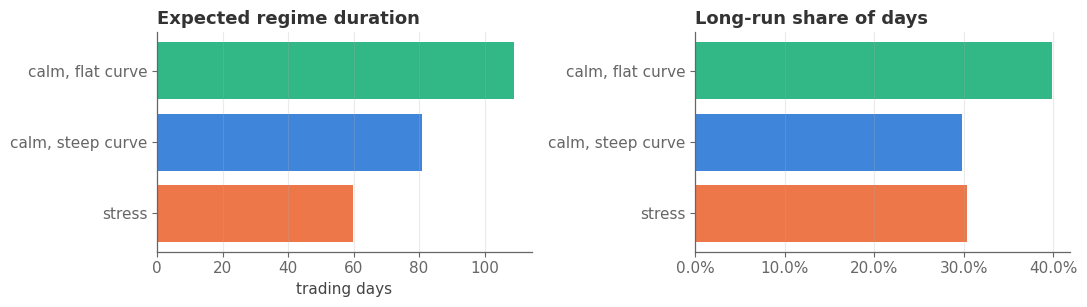

In [12]:
order = sorted(NAMES.values())              # stable display order
ids = [i for n in order for i, nm in NAMES.items() if nm == n]

tm = pd.DataFrame(hmm.transmat_[np.ix_(ids, ids)], index=order, columns=order)
print("fitted transition matrix, day to day:")
display(tm.round(4))

diag = np.array([hmm.transmat_[i, i] for i in ids])
duration = 1 / (1 - diag)

eigval, eigvec = np.linalg.eig(hmm.transmat_.T)
pi = np.real(eigvec[:, np.argmin(np.abs(eigval - 1))])
pi = pi / pi.sum()
pi = pi[ids]

summary = pd.DataFrame({'stickiness (stay prob)': diag,
                        'expected duration, days': duration,
                        'long-run share of days': pi}, index=order)
display(summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
colors = [COLORS[n] for n in order]
axes[0].barh(order, duration, color=colors, alpha=0.9)
axes[0].set_title('Expected regime duration')
axes[0].set_xlabel('trading days')
axes[1].barh(order, pi, color=colors, alpha=0.9)
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].set_title('Long-run share of days')
for ax in axes:
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.25)
    ax.grid(axis='y', alpha=0)
fig.tight_layout()

Three readings worth keeping:

1. **Regimes are sticky by construction of reality, not of the model.**
   Every diagonal is above 0.98; the fitted chain learned that tomorrow
   overwhelmingly repeats today. This is exactly the persistence the
   memoryless mixture had no way to express.
2. **When the market breaks, it stays broken for months.** Expected
   durations run to a few months of trading days each, with stress
   episodes averaging roughly a quarter rather than a bad week. Plan
   for stress as a season, not a storm.
3. **Stress is not rare.** The stationary distribution says the market
   spends close to a third of its long-run days in the stress regime.
   Any risk process that treats calm as the default and stress as an
   exception has the proportions wrong.

## The exam: years the model has never seen

Everything so far described the training window, where a flexible model
flattering itself is always a risk. So freeze the parameters, hand the
model 2022 onward (data from after its world ends), and see whether its
regime calls line up with what actually happened. I will tell you now
that the grade is mixed, and that the failing part of the exam is the
most instructive thing in this notebook.

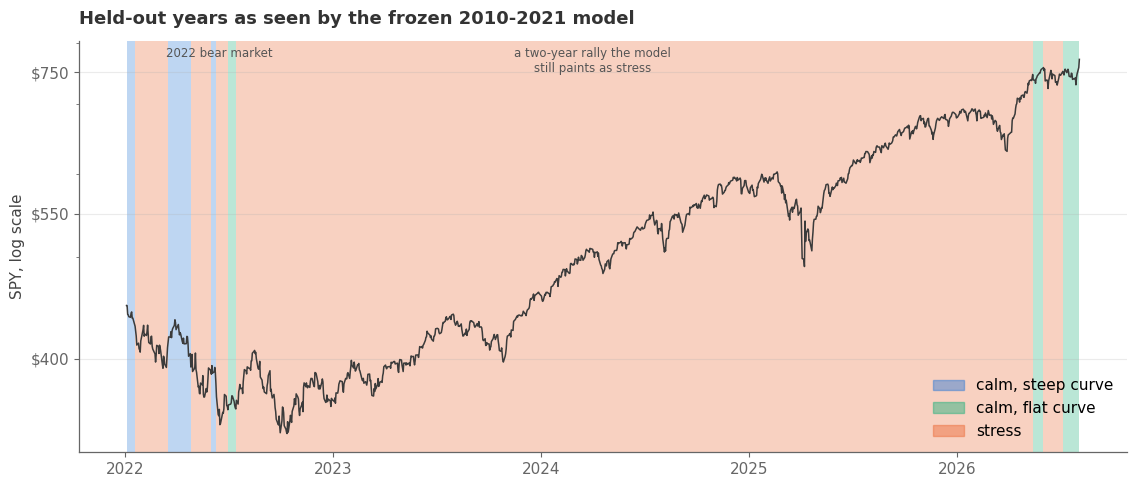

In [13]:
states_test = hmm.predict(X_test)
plot_regimes(test, states_test, NAMES,
             'Held-out years as seen by the frozen 2010-2021 model',
             notes=[('2022-06-15', '2022 bear market'),
                    ('2024-04-01', 'a two-year rally the model\nstill paints as stress')])

The first year goes well: the model, whose knowledge stops at New Year
2022, correctly paints the 2022 bear market as one long stress episode.
Then something goes visibly wrong. From 2023 through 2025 the market
staged a powerful rally with mostly ordinary volatility, and the frozen
model keeps calling stress almost without a break. A regime label that
stays "crisis" through two years of new highs is not describing the
market anymore.

This is worth diagnosing rather than hiding, because the mechanism is
one every practitioner eventually meets. Look at what the holdout years
did to our features, and at which state owns the widest emission
distribution.

In [14]:
print("fraction of days called stress, by year:")
display(test.assign(state=states_test)
        .groupby(test.index.year)['state']
        .apply(lambda s: (s == stress_id).mean()).round(2)
        .rename('stress share'))

macro = ['T10Y2Y', 'T10Y3M', 'VIXCLS']
rng_tbl = pd.DataFrame({'train min': train[macro].min(),
                        'train mean': train[macro].mean(),
                        'test min': test[macro].min(),
                        'test mean': test[macro].mean()})
print("\nwhere the holdout left the training distribution:")
display(rng_tbl.round(2))
print(f"share of holdout days with an inverted 10y-2y curve: "
      f"{(test['T10Y2Y'] < 0).mean():.0%}")

print("\ngeneralized variance of each emission Gaussian (det of covariance):")
for i in sorted(NAMES):
    print(f"  {NAMES[i]:<18}: {np.linalg.det(hmm.covars_[i]):.4f}")

fraction of days called stress, by year:


Date
2022    0.79
2023    1.00
2024    1.00
2025    1.00
2026    0.79
Name: stress share, dtype: float64


where the holdout left the training distribution:


,train min,train mean,test min,test mean
T10Y2Y,-0.04,1.34,-1.08,-0.01
T10Y3M,-0.52,1.68,-1.89,-0.21
VIXCLS,9.14,18.13,11.86,19.23


share of holdout days with an inverted 10y-2y curve: 47%

generalized variance of each emission Gaussian (det of covariance):
  calm, steep curve : 0.0008
  calm, flat curve  : 0.0003
  stress            : 0.1667


Now the failure explains itself, in three moves.

First, both calm states were defined by a *positively sloped* yield
curve (training means around two points and one point of 10y minus 2y
spread), and the training years never contained a meaningful
inversion: the training minimum is a hair below zero. Second, 2022's
rate shock inverted the curve for roughly half the holdout, to depths
the model had literally never seen, so those days fit neither calm
Gaussian no matter how quiet the price action was. Third, the stress
state's emission distribution is by far the widest, a few hundred
times the generalized variance of either calm state, so every
unfamiliar day loses its likelihood contest to the one state that
tolerates weirdness. Add the stickiness the chain learned, and stress
becomes a trap the frozen model cannot leave.

The general lesson is bigger than this notebook. An unsupervised
model, handed data from outside its training distribution, does not
raise its hand and say "unfamiliar". It shoves the new world into
whichever bucket is widest and keeps going, so out here "stress"
quietly stopped meaning *crisis* and started meaning *nothing I
recognize*. Only the out-of-sample exam revealed the difference. This
is why the exam exists, why production regime models carry drift
monitoring, and why they get refitted on a schedule with the naming
step re-earned each time, the way our `name_states` function already
allows.

## Honest limits, then takeaways

Limits first, because they are load-bearing:

1. **Distribution shift breaks frozen models, silently.** Demonstrated
   above at full scale: three years of miscalled regimes, with a
   mechanical explanation. A fitted HMM describes the world it saw,
   and rented descriptions expire.
2. **The regimes are creatures of the features.** Ours know about fear
   and the rate cycle because we fed them the VIX and the curve. That
   one choice produced both the interpretable calm split in training
   and the inversion blind spot in the holdout.
3. **Labels are not stable across refits.** Refit on a different window
   or seed and state 2 may become state 0. Any production use needs the
   naming-from-statistics step automated, as done here.
4. **The state count was a judgment call.** Defensible and documented,
   but a choice. BIC would have kept buying tail-fitting components
   forever.
5. **None of this is a trading signal.** The model describes; timing
   strategies on it is a different research program with its own
   graveyard.

And what deserves keeping:

1. An HMM is notebook 01's chain plus per-state emission
   distributions, fitted while the states stay invisible. On synthetic
   data that honors its assumptions, it demonstrably recovers the
   truth.
2. Validate the pipeline, not just the model: split before scaling,
   name states from statistics, and keep an untouched holdout for the
   final exam. Ours caught a real failure, which is the strongest
   argument for administering exams.
3. The transition matrix is the payload, not a by-product. Stickiness,
   durations, and the long-run share of stress came from three lines of
   notebook 01 algebra, and they are more decision-useful than the
   colored chart.

Notebook 04 takes the absorbing machinery from notebook 02 to a system
I work with daily, the multi-step AI agent, and shows the two
repositories in this series agreeing on the same numbers by completely
different methods.

---

*Satsawat Natakarnkitkul · [satsawat.ai](https://satsawat.ai) ·
[AI in Practice newsletter](https://satsawat.ai/#newsletter)*